# Prepare Data

In [ ]:
import emulator.interpolator.util as util
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np
import corner
import os
from scipy.interpolate import interp1d
from IPython.display import display
%matplotlib widget
def show_active():
    fig = plt.gcf()
    display(fig)
    plt.close(fig)

# Fit settings
fit_max_wav = 7000 # 10000
fit_min_wav = 5100 # 4250

# Get model data
param_names, X, y, wav_mod = util.read_runs('new_atomic_runs')

# Get observed data
obs_df = pd.read_csv('calibrated_spectra/2020jfo-2020-05-19.csv')
wav_obs = obs_df['wavelength']
y_obs = obs_df['flux']
y_obs_err = y_obs * 0.01 # obs_df['fluxerr']

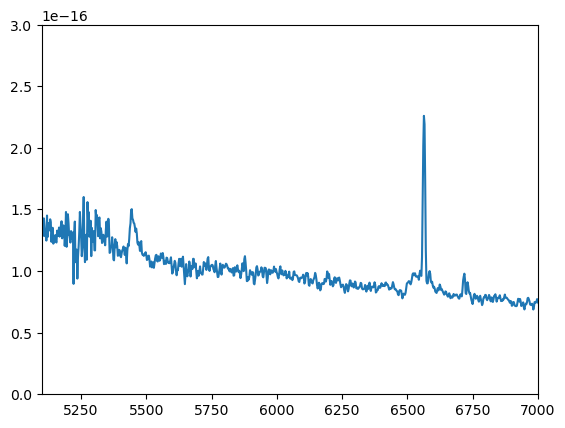

In [20]:
if True:
    obs_df = pd.read_csv('calibrated_spectra/2020hgw-2020-05-23.csv')
    wav_obs = obs_df['wavelength']
    y_obs = obs_df['flux']
    plt.figure()
    plt.plot(wav_obs, y_obs)
    plt.xlim(5100, 7000)
    plt.ylim(0, 3e-16)
    show_active()

2020jfo-2020-05-19.csv
2020jww-2020-05-23.csv
2020rth-2020-08-24.csv
2020hgw-2020-05-23.csv


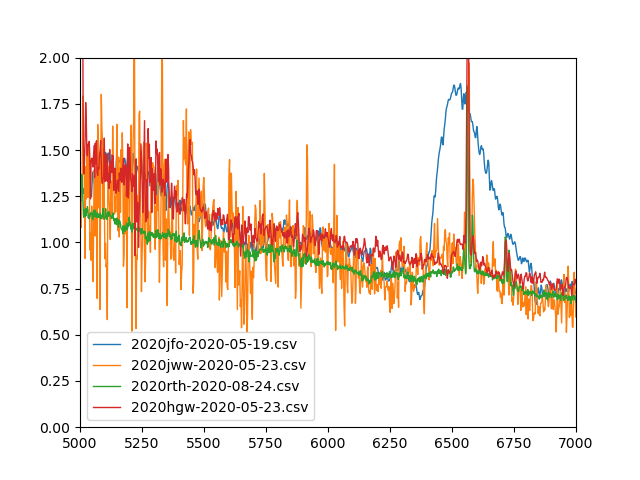

In [21]:
if True:
    spec_dir = 'calibrated_spectra/'
    plt.figure()

    for name in os.listdir(spec_dir):
        spec_path = os.path.join(spec_dir, name)
        if os.path.isfile(spec_path):
            print(name)
            df = pd.read_csv(spec_path)
            wav_obs = df['wavelength']
            y_obs = df['flux']
            plt.plot(wav_obs, y_obs / np.mean(y_obs), label=name, lw=1)
    plt.legend()
    plt.xlim(5000, 7000)
    plt.ylim(0, 2)
    plt.show()

In [4]:
# Initialize model data file
if False:
    folder_path = os.path.dirname('C:/Users/mikel/Desktop/new_atomic_runs/')
    param_names = ['log_lsun', 't_exp', 'v_start', 'X', 'Z', 'n']
    util.save_runs(folder_path, param_names, 'new_atomic_runs')

In [ ]:
# Mask to fitting range
mask = (wav_obs < fit_max_wav) & (wav_obs > fit_min_wav)
wav_obs = wav_obs[mask]
y_obs = y_obs[mask]
y_obs_err = y_obs_err[mask]

# Remove any spectra containing negative fluxes
mask = np.all(y >= 0, axis=1)
X = X[mask]
y = y[mask]

# Remove the out of range model data
mask = (wav_mod >= wav_obs.min()) & (wav_mod <= wav_obs.max())
wav_mod = wav_mod[mask]
y = y[:, mask]

# Interpolate onto new wavelength grid
dx = np.max([np.abs(wav_mod[-1] - wav_mod[-2]), np.abs(wav_mod[1] - wav_mod[0])])
wav = np.arange(wav_mod.min(), wav_mod.max(), dx)
y = interp1d(wav_mod, y, bounds_error=False)(wav)
y_obs = interp1d(wav_obs, y_obs, bounds_error=False)(wav)
y_obs_err = interp1d(wav_obs, y_obs_err, bounds_error=False)(wav)

# Setup fitting parameters
max_scale = np.log10(np.max(y) / np.min(y_obs))
min_scale = np.log10(np.min(y) / np.max(y_obs))

limits = list(zip(np.min(X, axis=0), np.max(X, axis=0)))
sampler_names = np.array(list(param_names.copy()) + ['log_scale'])
sampler_limits = np.array(limits.copy() + [(min_scale, max_scale)])
ndim = len(sampler_names)

print(pd.DataFrame({'name': sampler_names, 'limits': list(sampler_limits)}))

        name                                      limits
0   log_lsun      [7.320048387505541, 9.119777760813308]
1      t_exp    [13.000351735429357, 17.499826646050224]
2    v_start      [5600.420224087724, 6999.813431204112]
3          X     [0.550034701281516, 0.8499759474771581]
4          Z  [0.0005011675428490001, 0.049998573782612]
5          n     [9.000449728825751, 10.999786964119368]
6  log_scale      [50.36081378986122, 53.47442722483497]


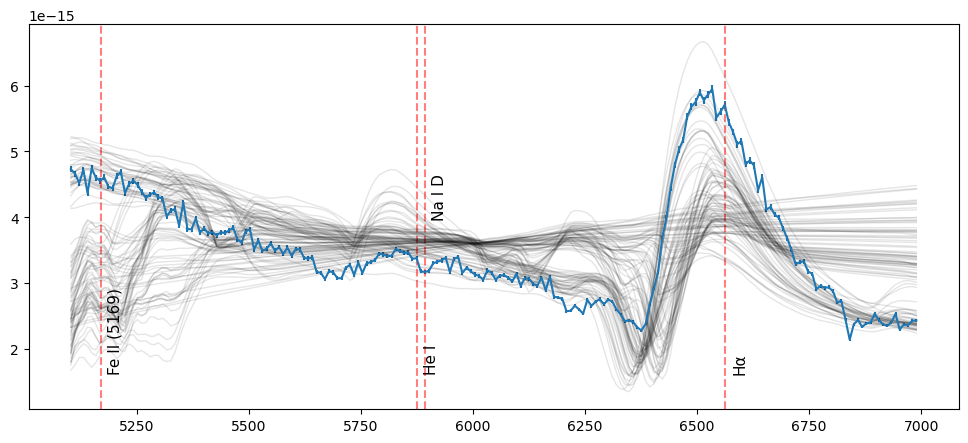

In [6]:
# View observed data
plt.figure(figsize=(12, 5))
plt.errorbar(wav, y_obs, yerr=y_obs_err, ms=1)
util.label_common_features()

# Overlay models
for y_mod in y[:100]:
    plt.plot(wav, y_mod / np.mean(y_mod) * np.mean(y_obs), c='black', lw=1, alpha=0.1)

show_active()

12.72797231168409 Mpc
X: {'log_lsun': 8.237441538492993, 't_exp': 14.383062728179908, 'v_start': 6054.035823510432, 'X': 0.619867522867105, 'Z': 0.004686225504186001, 'n': 10.972546115993666}
log_scale: 52.2874293982249


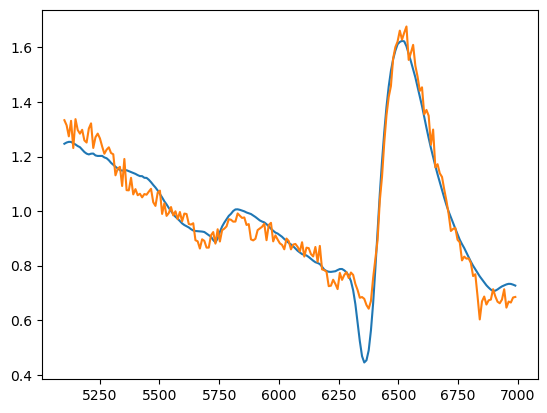

In [7]:
# Simple minimze MSE fit
y_obs_norm = y_obs / np.mean(y_obs)

mse = []
for y_mod in y:
    y_mod_norm = y_mod / np.mean(y_mod)
    mse.append(np.mean((y_mod_norm - y_obs_norm)**2))

lowest_i = np.argmin(mse)
X_best = X[lowest_i]
y_best = y[lowest_i]

plt.figure()
plt.plot(wav, y_best / np.mean(y_best))
plt.plot(wav, y_obs / np.mean(y_obs))

scale = np.mean(y_best) / np.mean(y_obs)
distance = util.distance(np.mean(y_best) / np.mean(y_obs))
print(distance)
print('X:', dict(zip(sampler_names, X_best)))
print('log_scale:', np.log10(scale))

show_active()

Spectra shape: (8556, 204)


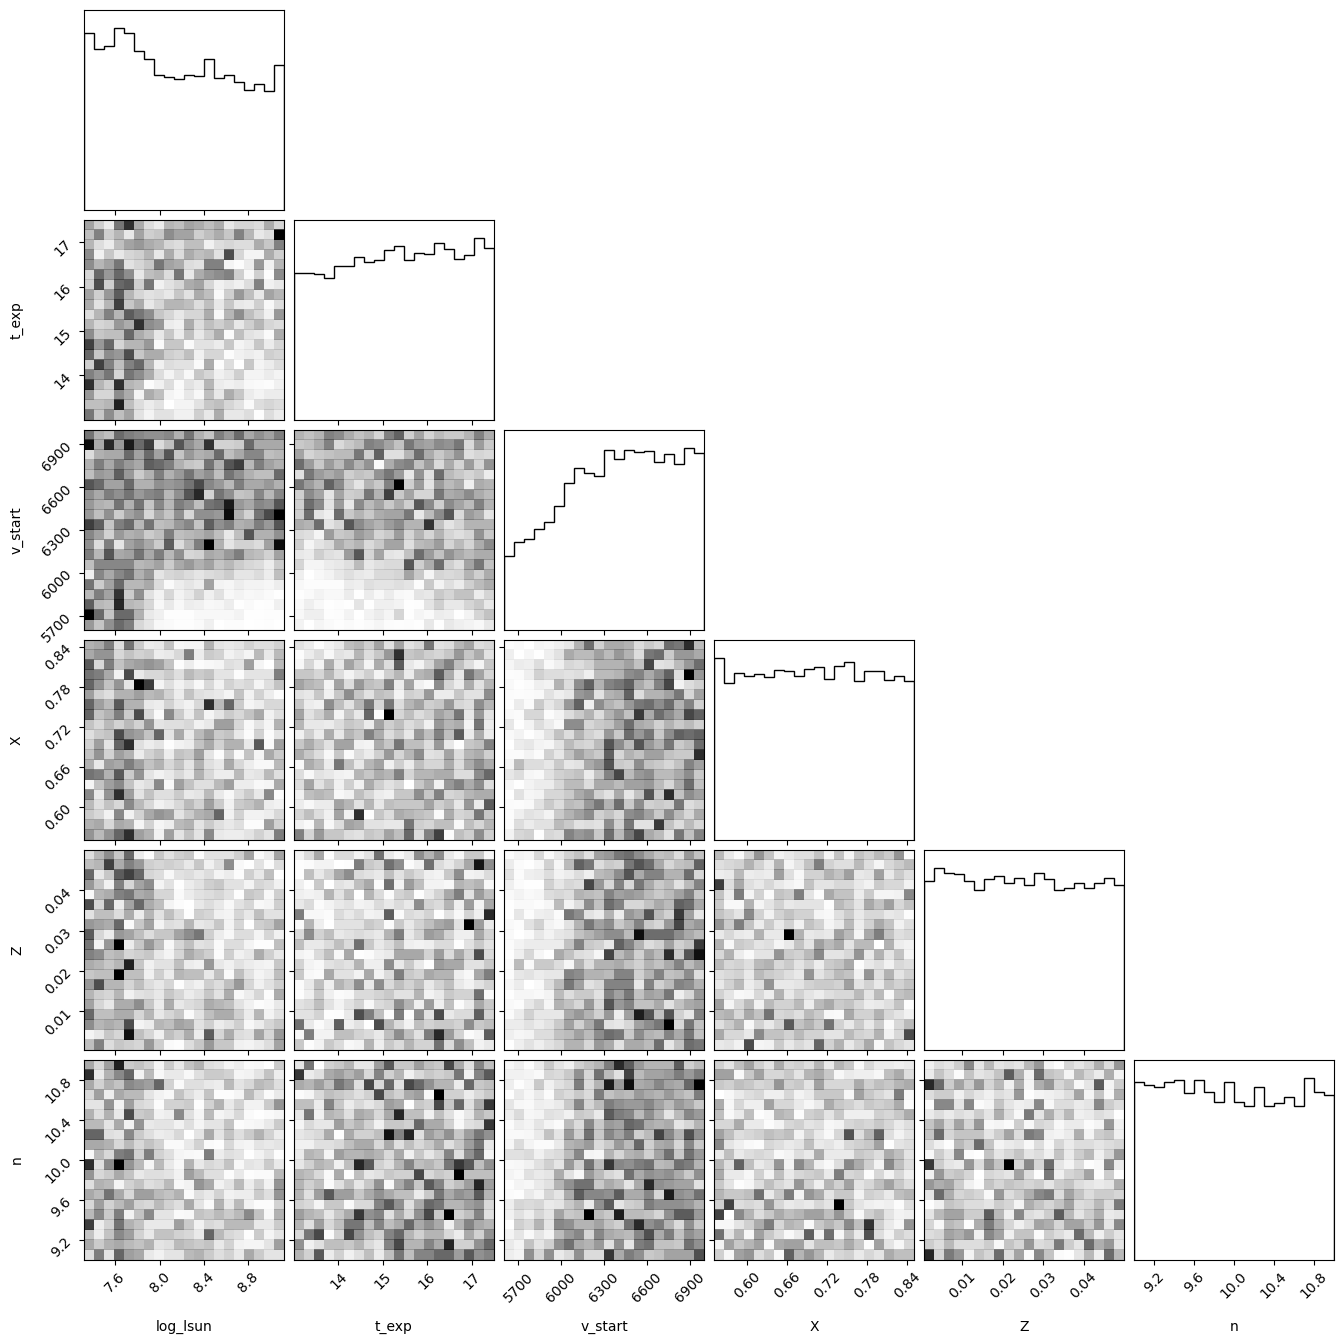

In [8]:
# Visualize sampling coverage
print('Spectra shape:', y.shape)
fig = corner.corner(
    X,
    labels=param_names,
    range=limits,
    bins=20,
    plot_contours=False,
    plot_datapoints=False,
    plot_density=True,
)
show_active()

# Train Models

In [9]:
# Settings
use_linear = False

In [10]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [11]:
# Linear interpolator
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)
interp_linear_scaled = LinearNDInterpolator(X_scaled, y_train)
interp_nearest_scaled = NearestNDInterpolator(X_scaled, y_train)

def interp(X, force_nearest=False):
    if X.ndim == 1:
        X_scaled = scaler.transform(X.reshape(1, -1))
    else:
        X_scaled = scaler.transform(X)
    y = interp_linear_scaled(X_scaled)
    if np.any(np.isnan(y)) or force_nearest:
        return interp_nearest_scaled(X_scaled)
    else:
        return y

In [12]:
# MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

mlp = MLPRegressor(
    max_iter=10000, alpha=1e-5, tol=1e-7, learning_rate_init=1e-3, hidden_layer_sizes=(64, 128, 64), early_stopping=False
)
model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('x_scaler', StandardScaler()),
        ('mlp', mlp),
    ]),
    transformer=StandardScaler(),
)
model.fit(X_train, y_train)
print('Iterations:', model.regressor_.named_steps['mlp'].n_iter_)

Iterations: 177


In [13]:
# Find hyperparameters
if False:
    from sklearn.neural_network import MLPRegressor
    from sklearn.model_selection import GridSearchCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import mean_squared_error

    mlp = MLPRegressor(
        max_iter=10000, tol=1e-6, early_stopping=True
    )
    model = TransformedTargetRegressor(
        regressor=Pipeline([
            ('x_scaler', StandardScaler()),
            ('mlp', mlp),
        ]),
        transformer=StandardScaler(),
    )

    param_grid = {
        'regressor__mlp__hidden_layer_sizes': [
            (32,),
            (64,),
            (128,),
            (64, 64),
            (128, 64),
            (128, 128),
        ],
        'regressor__mlp__alpha': [
            1e-5,
            1e-4,
            1e-3,
            1e-2,
        ],
        'regressor__mlp__learning_rate_init': [
            1e-4,
            5e-4,
            1e-3,
        ]
    }

    search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    print(results[['param_regressor__mlp__hidden_layer_sizes', 'std_test_score']])

    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print('Test MSE:', mse)
    print(search.best_params_)


In [14]:
def calc_y(X_mod, force_nearest=False):
    if use_linear or force_nearest:
        return interp(X_mod, force_nearest)[0]
    else:
        return model.predict(X_mod.reshape(1, -1))[0]

# Model Diagnositcs

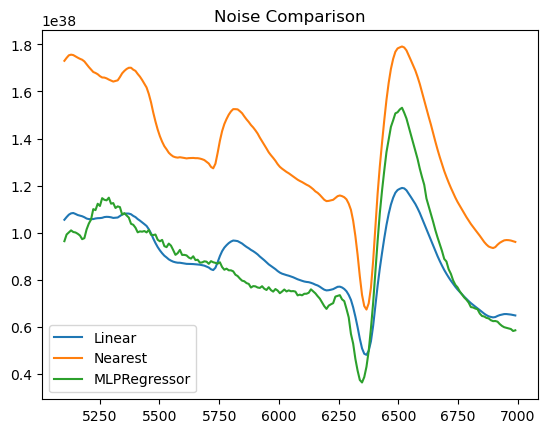

mean mfe: 2.8e-01


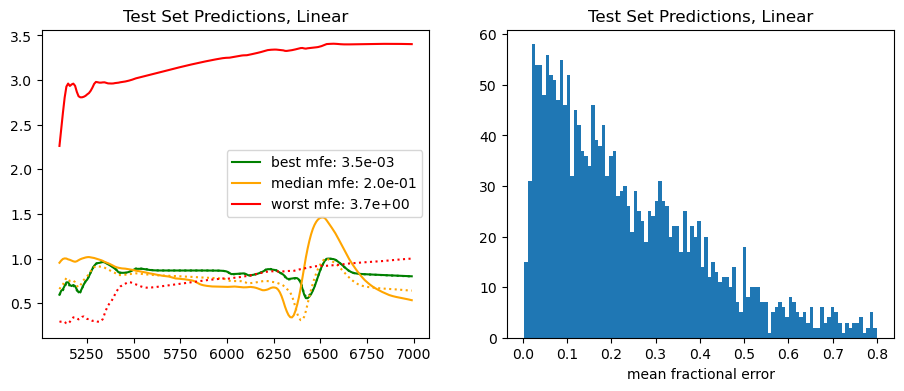

mean mfe: 6.5e-02


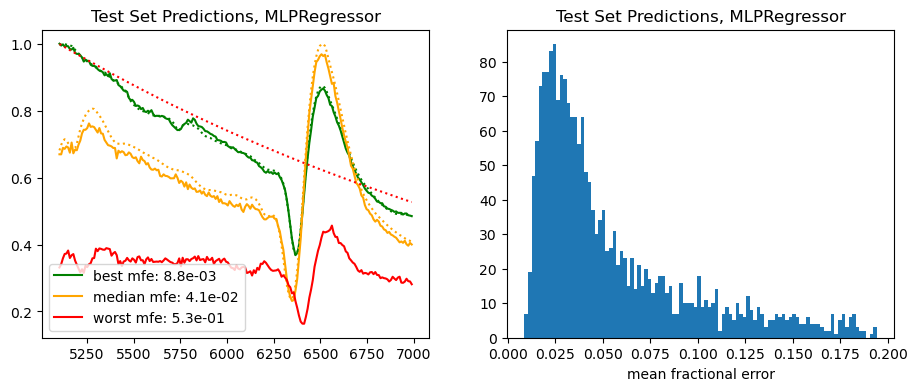

In [15]:
# Compare noise
plt.figure()
X_diag = np.mean(limits, axis=1)
# X_diag = X_best
plt.plot(wav, interp(X_diag, force_nearest=False)[0], label='Linear')
plt.plot(wav, interp(X_diag, force_nearest=True)[0], label='Nearest')
y_mod = model.predict(X_diag.reshape(1, -1))[0]
plt.plot(wav, y_mod, label='MLPRegressor')
plt.title('Noise Comparison')
plt.legend()
show_active()

# The histogram excludes mfe values larger than the 95th percentile, since there's a few outliers
util.evaluate_predictions(y_test, interp(X_test), wav, 'Test Set Predictions, Linear')
show_active()
util.evaluate_predictions(y_test, model.predict(X_test), wav, 'Test Set Predictions, MLPRegressor')
show_active()

# Scipy Fit

In [23]:
# Scipy differential evolution
results = []

def f(x):
    scale = 10**x[-1]
    X_mod = x[:-1]
    y_mod = calc_y(X_mod, force_nearest=False)
    y1 = y_mod/scale
    y2 = y_obs
    y2err = y_obs_err
    like = (((y1 - y2) / y2err)**2).sum()
    return like

from scipy.optimize import differential_evolution
sampler_start = list(np.mean(limits, axis=1)) + [(min_scale + max_scale) / 2]
result = differential_evolution(f, x0=sampler_start, bounds=sampler_limits, tol=1e-6)

X_mod = result.x[:-1]
scale = 10**result.x[-1]

plt.figure()
plt.plot(wav, y_obs * scale, label='Observed')
plt.plot(wav, calc_y(X_mod), label='Model')
plt.plot(wav, calc_y(X_mod, force_nearest=True), label='Nearest')
plt.title('Differential Evolution Fit')
plt.legend()
util.label_common_features()
show_active()

distance = util.distance(scale)
print('distance:', distance.to(u.Mpc))
print('log_scale = ', result.x[-1])
print('data = ', dict(zip(sampler_names, X_mod)))

RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

# Visualize Parameters

ValueError: x and y must have same first dimension, but have shapes (204,) and (3025,)

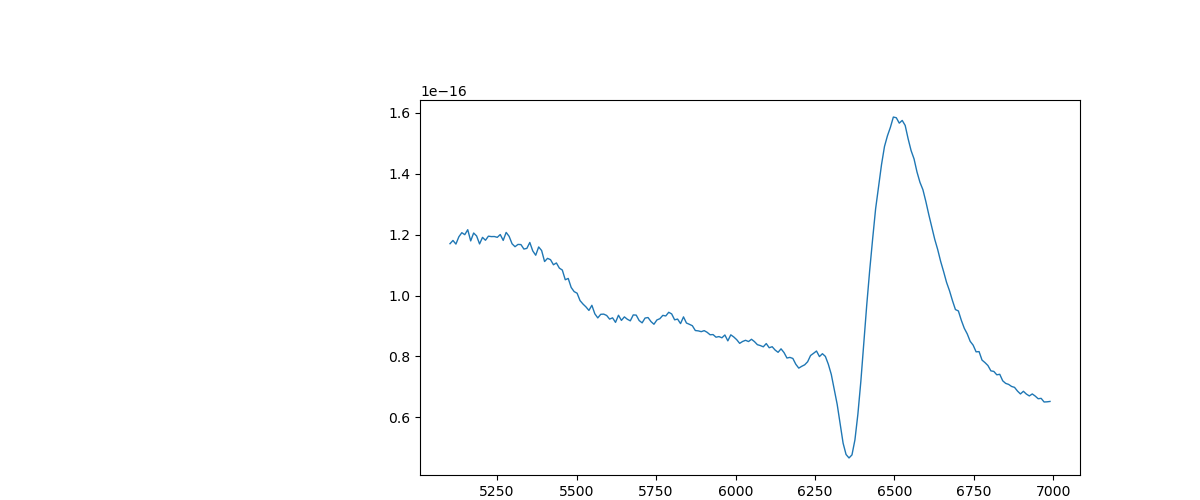

In [22]:
overlay_observed = True
show_interp = True
show_nearest = False
best_fit_ics = True
autoscale_view = False

# Initialize
from matplotlib.widgets import Slider
active_vals = None
if best_fit_ics:
    active_vals = X_mod
else:
    active_vals = sampler_start

fig, ax = plt.subplots(figsize=(12, 5))
fig.subplots_adjust(left=0.35, bottom=0.05, top=0.8)
fig.canvas.toolbar_position = 'bottom'

# Create figure elements
line1 = None
line2 = None
if show_interp:
    line1, = ax.plot(wav, np.empty_like(wav), lw=1, label='Model')
if show_nearest:
    line2, = ax.plot(wav, np.empty_like(wav), lw=1, label='Nearest')
if overlay_observed:
    ax.plot(wav, y_obs, label='Observed')
util.label_common_features()

text_X = ax.text(
    0, 1.2,
    'X: {}',
    transform=ax.transAxes
)

text_dist = ax.text(
    0, 1.15,
    'Distance: 0',
    transform=ax.transAxes
)

# Main update function
def redraw(initial=False):
    scale = 1
    if line1:
        y_mod = calc_y(active_vals)
        if overlay_observed:
            scale = np.nanmean(y_obs) / np.nanmean(y_mod)
        line1.set_ydata(y_mod * scale)

        vals_formatted = [f'{x:.3f}' for x in active_vals]
        text_X.set_text('X: ' + str(dict(zip(sampler_names, vals_formatted))))
        text_dist.set_text('Distance: ' + str(util.distance(1/scale)))
    if line2:
        y_mod = calc_y(active_vals, force_nearest=True)
        if overlay_observed:
            scale = np.nanmean(y_obs) / np.nanmean(y_mod)
        line2.set_ydata(y_mod * scale)

        if not line1:
            mask = np.isclose(y, y_mod).all(axis=1)
            index = np.where(mask)[0][0]
            vals_formatted = [f'{x:.3f}' for x in X[index]]
            text_X.set_text('X: ' + str(dict(zip(sampler_names, vals_formatted))))
            text_dist.set_text('Distance: ' + str(util.distance(1/scale)))
    if autoscale_view or initial:
        ax.relim()
        ax.autoscale_view()
    fig.canvas.draw_idle()

# Make sliders
sliders = []
for index, name in enumerate(param_names):
    ax_slider = fig.add_axes([0.025 + 0.25 * index / 5, 0.05, 0.0225, 0.9])
    slider = Slider(
        ax=ax_slider,
        label=param_names[index],
        valmin=limits[index][0],
        valmax=limits[index][1],
        valinit=active_vals[index],
        orientation='vertical'
    )
    def make_update(index):
        def update(val):
            active_vals[index] = val
            redraw()
        return update
    slider.on_changed(make_update(index))
    sliders.append(slider)

redraw(True)
ax.legend()
plt.show()

In [18]:
print(limits[2])

(5600.420224087724, 6999.813431204112)


In [19]:
from astropy.constants import sigma_sb
def blackbody_L(t_exp, T, v):
    r = v*t_exp
    L = 4*np.pi*r**2 * sigma_sb * T**4
    return L.to(u.erg/u.s)

T = 6000 * u.K
v = 6000 * u.km/u.s
t_min = 13*u.day # limits[1][0] * u.day
t_max = 17.5*u.day # limits[1][1] * u.day
v_min = 6000*u.km/u.s
v_max = 7000*u.km/u.s

print('Best fit = 8.237')
L_min = blackbody_L(t_min, T, v_min)
L_max = blackbody_L(t_max, T, v_max)
print(t_min, ':', util.to_loglsun(L_min))
print(t_max, ':', util.to_loglsun(L_max))

Best fit = 8.237
13.0 d : 8.039671363429026
17.5 d : 8.431754335449169


# UltraNest Fit

In [17]:
import ultranest
import ultranest.stepsampler
from ultranest.plot import cornerplot

def uniform_prior(quantile, min, max):
    return quantile * (max - min) + min
def log_uniform_prior(quantile, min, max):
    return 10**(quantile * (np.log10(max) - np.log10(min)) + np.log10(min))

def prior_transform(cube):
    params = cube.copy()
    for i in range(len(cube)):
        params[i] = uniform_prior(cube[i], *sampler_limits[i])
    return params

def likelihood(params):
    scale = 10**params[-1]
    active_vals = params[:-1]
    y_mod = calc_y(active_vals)
    y1 = y_mod/scale
    y2 = y_obs
    y2err = y_obs_err
    like = -0.5 * (((y1 - y2) / y2err)**2).sum()
    return like

In [18]:
# Step sampler
sampler = ultranest.ReactiveNestedSampler(list(sampler_names), likelihood, prior_transform) #, log_dir='ultranest/1', storage_backend='csv')
sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(nsteps=2*ndim)

result = sampler.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+03  176.17 [-3177.1519..-3177.1519]*| it/evals=22101/1795163 eff=1.2314% N=400  0   
[ultranest] Likelihood function evaluations: 1795163
[ultranest]   logZ = -3227 +- 0.2619
[ultranest] Effective samples strategy satisfied (ESS = 3331.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.24 to 0.52, need <0.5)
[ultranest]   logZ error budget: single: 0.34 bs:0.26 tail:0.01 total:0.26 required:<0.50
[ultranest] done iterating.



logZ = -3227.567 +- 0.525
  single instance: logZ = -3227.567 +- 0.341
  bootstrapped   : logZ = -3227.488 +- 0.525
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 0.48 (should be >1), far enough fraction: 19.14% : very fishy. Double nsteps and see if fraction and lnZ change)

    log_lsun            : 8.3678│ ▁▁ ▁▁▁▁▁▁▂▂▃▄▅▆▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁ ▁▁ │8.3828    8.3749 +- 0.0017
    t_exp               : 17.42811│ ▁▁ ▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▆▅▄▃▂▁▁▁▁▁ ▁▁ │17.43608    17.43284 +- 0.00073
    v_start             : 5904.7│ ▁   ▁ ▁▁▁▁▁▁▁▁▁▁▁▂▂▄▅▇▇▇▆▄▃▂▁▁▁▁▁▁  ▁ │5921.5    5914.8 +- 1.3
    X                   : 0.75346│ ▁  ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▅▆▇▇▇▇▅▄▃▂▁▁▁▁▁ │0.75756    0.75623 +- 0.00038
    Z                   : 0.017867│ ▁  ▁▁▁▁▁▁▁▂▂▃▄▅▆▆▆▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │0.018454    0.018155 +- 0.000065
    n                   : 10.4097│ ▁ ▁▁▁▁▁▃▅▇▇▇▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁     ▁ │10.4472    10.4213 +- 0.0027
    log_sc

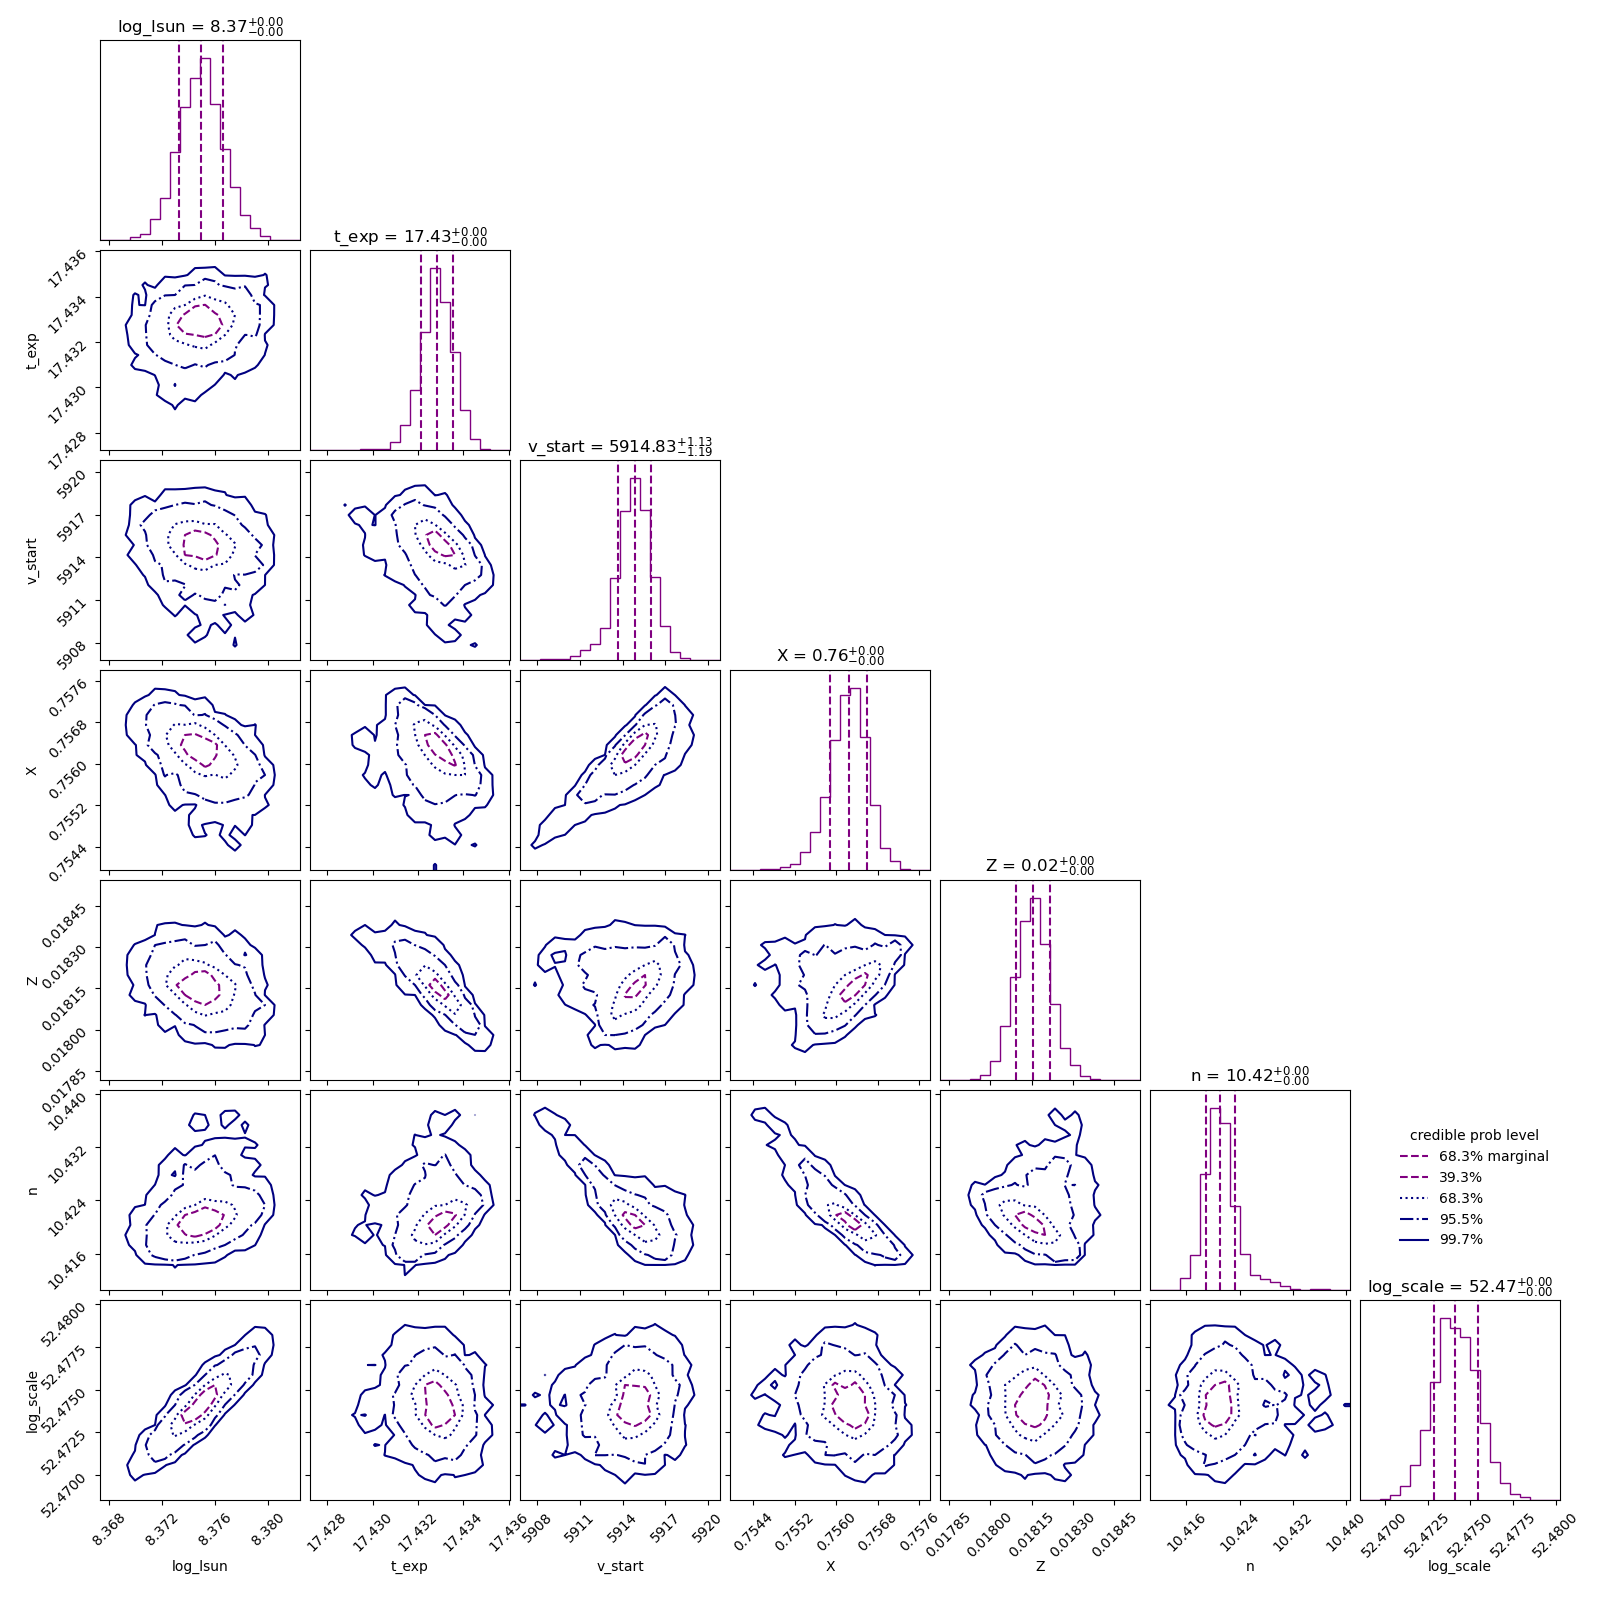

In [24]:
sampler.print_results()
sampler.plot_corner()

In [20]:
print(sampler.results.keys())
print(pd.DataFrame({'name': sampler_names, 'max likelihood': sampler.results['maximum_likelihood']['point']}))

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])
        name  max likelihood
0   log_lsun        8.374353
1      t_exp       17.433111
2    v_start     5914.575992
3          X        0.756341
4          Z        0.018151
5          n       10.420656
6  log_scale       52.473439


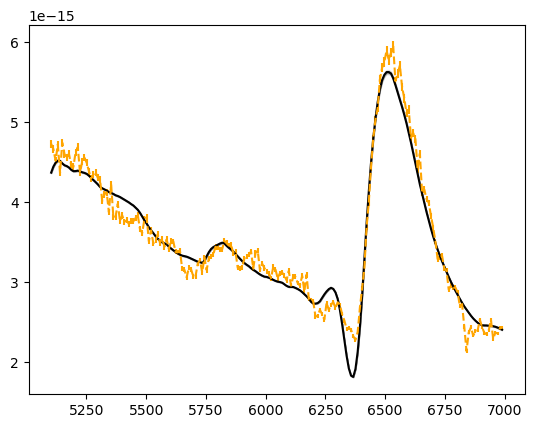

In [21]:
plt.figure()
plt.errorbar(wav, y_obs, yerr=np.abs(y_obs_err),
             marker='none', ls='--', color='orange')

from ultranest.plot import PredictionBand
band = PredictionBand(wav)

for X_i in sampler.results['samples']:
    scale = 10**X_i[-1]
    X_mod = X_i[:-1]
    y_mod = calc_y(X_mod)
    band.add(y_mod / scale)

band.line(color='k')
# add 1 sigma quantile
band.shade(color='k', alpha=0.3)
# add wider quantile (0.01 .. 0.99)
band.shade(q=0.49, color='gray', alpha=0.2)

show_active()

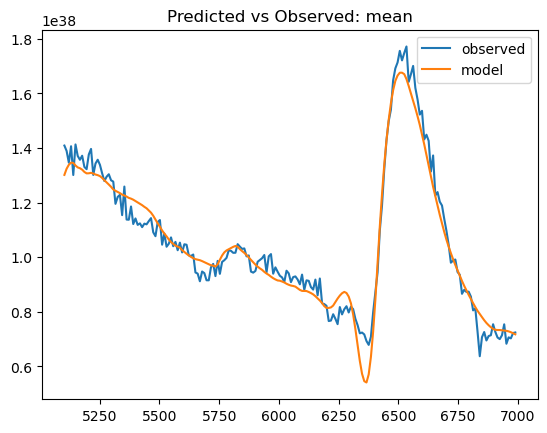

scale: 2.97953874487778e+52
distance: 15.78043756776509 Mpc
X: [8.37362611e+00 1.74342759e+01 5.91324030e+03 7.56038657e-01
 1.80362221e-02 1.04219552e+01]


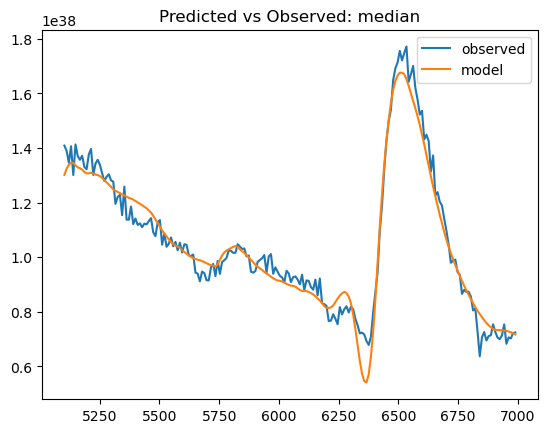

scale: 2.979378391216554e+52
distance: 15.780012924019283 Mpc
X: [8.37362611e+00 1.74342759e+01 5.91324030e+03 7.56038657e-01
 1.80362221e-02 1.04219552e+01]


In [22]:
for type, params in (('mean', result['posterior']['mean']), ('median', result['posterior']['median'])):
    scale = 10**params[-1]
    active_vals = np.array(params[:-1])
    y_mod = calc_y(active_vals)

    plt.figure()
    plt.plot(wav, y_obs * scale, label='observed')
    plt.plot(wav, y_mod, label='model')

    plt.title('Predicted vs Observed: ' + type)
    plt.legend()
    show_active()
    distance = util.distance(scale)
    
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))
    print('X:', X_mod)

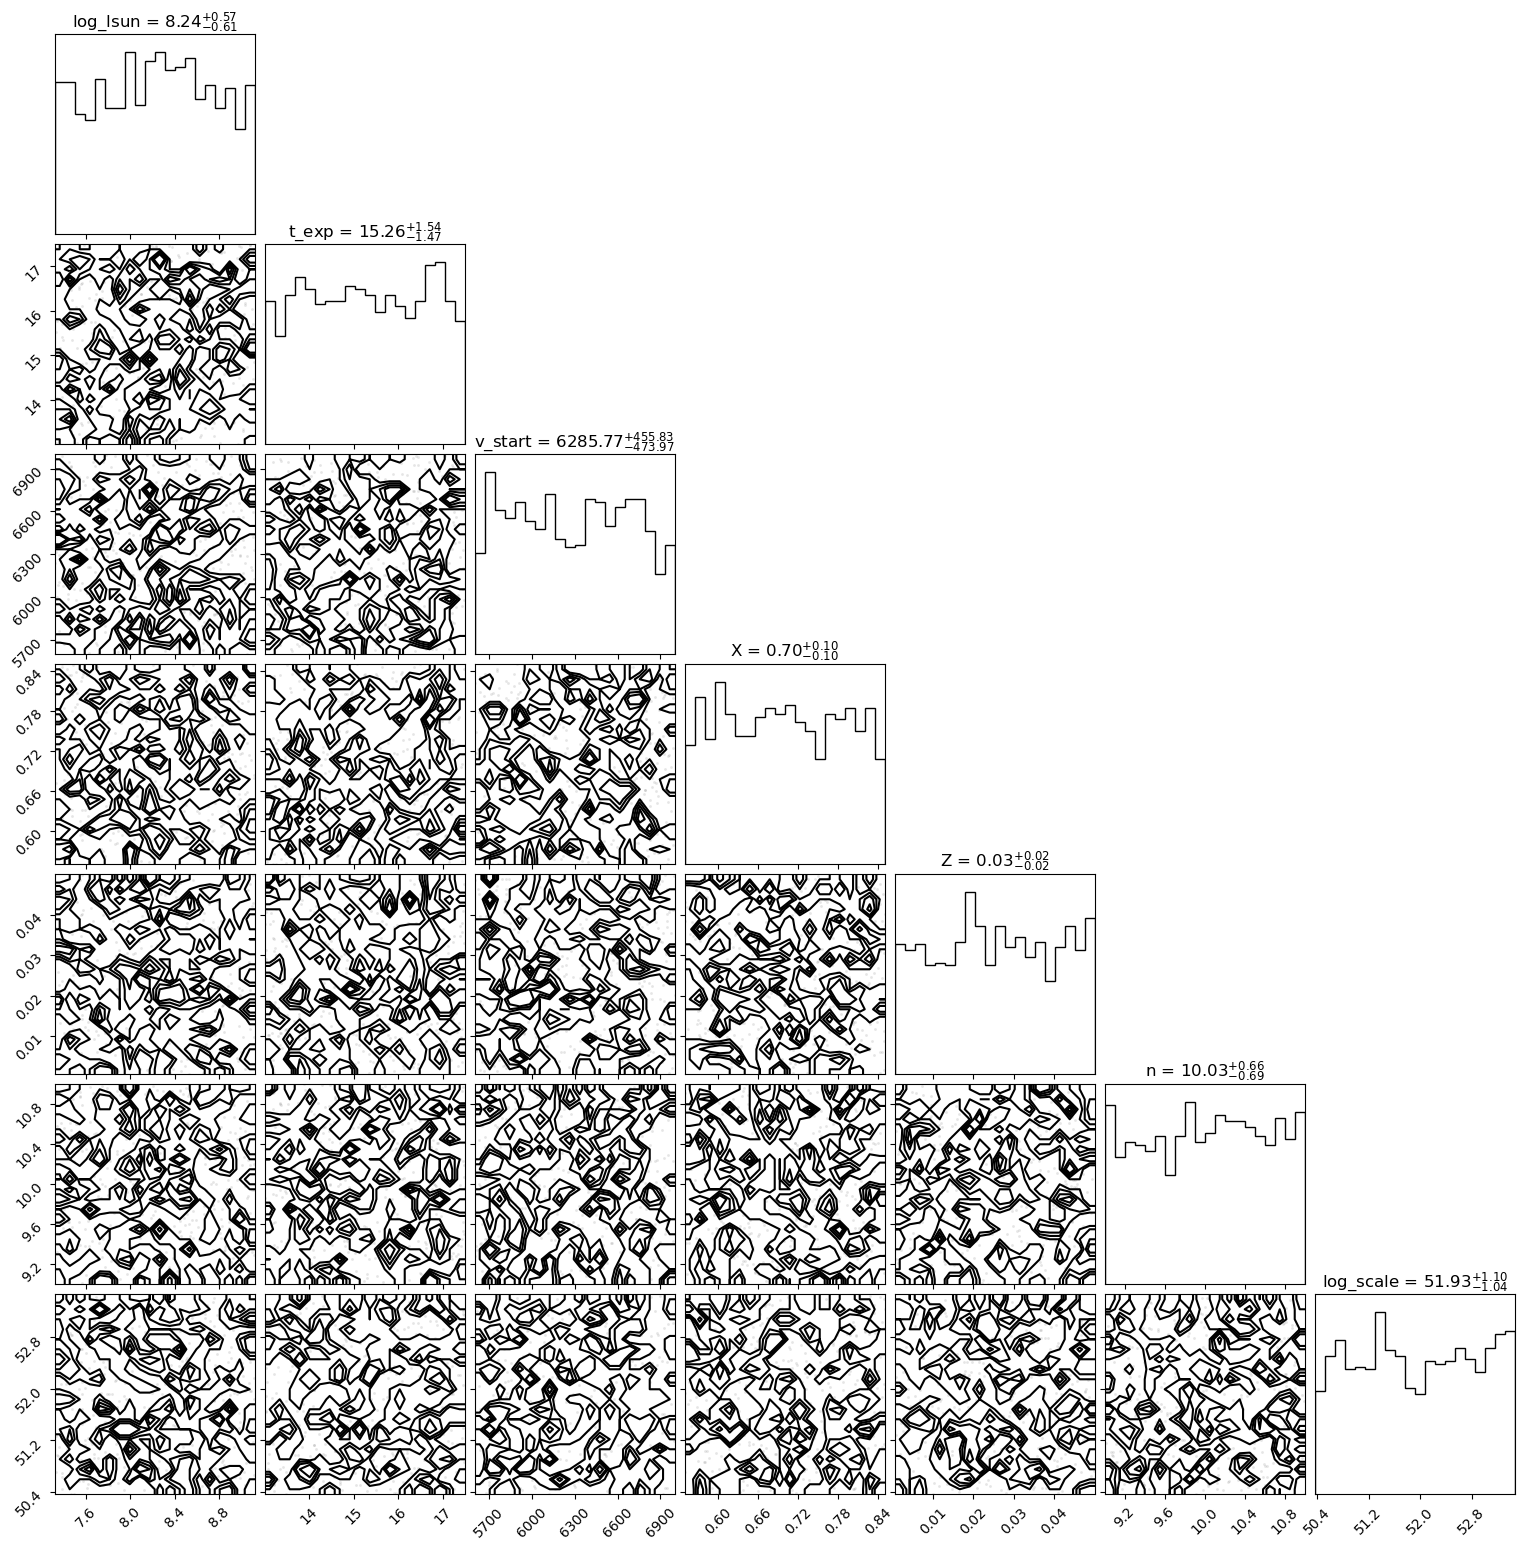

ValueError: X has 3 features, but MinMaxScaler is expecting 6 features as input.

In [23]:
# Diagnostics
def evaluate_performance():
    u = np.random.uniform(size=ndim)
    p = prior_transform(u)
    %timeit prior_transform(u)
    %timeit likelihood(p)
#evaluate_performance()

# Corner plot of a bunch of prior samples
p = np.array([prior_transform(np.random.uniform(size=ndim)) for i in range(1000)])
corner.corner(p, titles=sampler_names, show_titles=True, plot_density=False, quiet=True)
show_active()

# Plot evolution of likelihood over parameter range
vals = np.linspace(0, 1, 200)
p = np.array([prior_transform(np.array([0.5, v, 0.5, 0.5])) for v in vals])
like = np.array([likelihood(v) for v in p])

plt.figure()
plt.plot(vals, like)
show_active()